# **Data Ingestion and Integrity Validation**

---

Metadata Parsing: Load and inspect train.csv to map every
image_id to its corresponding integer label (0 to 4).

Corrupt File Check: Iterate through the image paths to check for unreadable, truncated, or missing .jpg files so they don't crash your training loop later.

In [21]:
# imports

import os
import pandas as pd
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
# Define paths based on your Google Drive structure
PROJECT_ROOT = "/content/drive/MyDrive/cassava_leaf_disease_classification"
RAW_DATA_DIR = os.path.join(PROJECT_ROOT, "data/raw")

In [26]:
# Save Split Manifests to Google Drive (MLOps Best Practice)
PROCESSED_DATA_DIR = os.path.join(PROJECT_ROOT, "data/processed")
os.makedirs(PROCESSED_DATA_DIR, exist_ok=True)

# save visualization and images here
OUTPUT_IMG_DIR = os.path.join(PROJECT_ROOT, "output/image")
os.makedirs(OUTPUT_IMG_DIR, exist_ok=True)

In [17]:
# locate train.csv and the image directory within raw/
csv_path = os.path.join(RAW_DATA_DIR, "train.csv")
train_images_dir = os.path.join(RAW_DATA_DIR, "train_images")
OUTPUT_IMG_DIR = os.path.join(PROJECT_ROOT, "output/image")

# Ensure the output image directory exists
os.makedirs(OUTPUT_IMG_DIR, exist_ok=True)


print(f"csv_path: {csv_path} \ntrain_images_dir: {train_images_dir}")

csv_path: /content/drive/MyDrive/cassava_leaf_disease_classification/data/raw/train.csv 
train_images_dir: /content/drive/MyDrive/cassava_leaf_disease_classification/data/raw/train_images


In [7]:
# Load the metadata
df = pd.read_csv(csv_path)

print(f"\nTotal rows in metadata (train.csv): {len(df)}")
display(df.head(10))


Total rows in metadata (train.csv): 21397


,image_id,label
0,1000015157.jpg,0
1,1000201771.jpg,3
2,100042118.jpg,1
3,1000723321.jpg,1
4,1000812911.jpg,3
5,1000837476.jpg,3
6,1000910826.jpg,2
7,1001320321.jpg,0
8,1001723730.jpg,4
9,1001742395.jpg,3



Visualization successfully saved to: /content/drive/MyDrive/cassava_leaf_disease_classification/output/image/unprocessed_raw_image.png


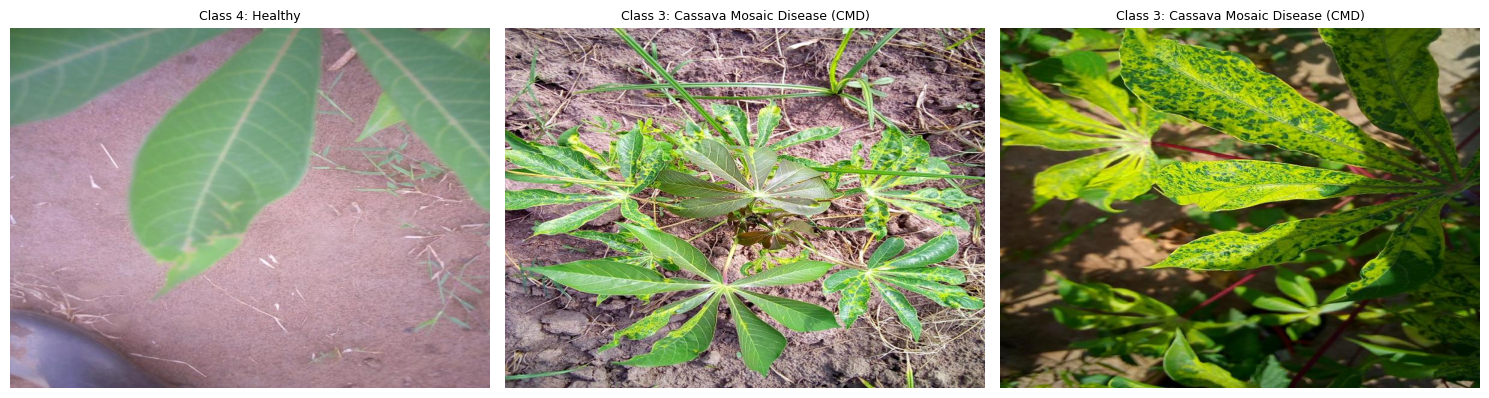

In [19]:
# ======= VISUALIZE & SAVE 3 SAMPLE IMAGES =======
# Mapping dictionary for the 5 Cassava classes
label_map = {
    0: "Cassava Bacterial Blight (CBB)",
    1: "Cassava Brown Streak Disease (CBSD)",
    2: "Cassava Green Mite (CGM)",
    3: "Cassava Mosaic Disease (CMD)",
    4: "Healthy"
}

# Grab 3 random samples from the dataframe
sample_df = df.sample(3, random_state=42)

plt.figure(figsize=(15, 5))
for i, (_, row) in enumerate(sample_df.iterrows()):
    img_name = row['image_id']
    label_idx = row['label']
    label_desc = label_map.get(label_idx, "Unknown")

    img_path = os.path.join(train_images_dir, img_name)

    # Open image using PIL
    img = Image.open(img_path)

    # Plotting
    plt.subplot(1, 3, i + 1)
    plt.imshow(img)
    plt.title(f"Class {label_idx}: {label_desc}", fontsize=9, wrap=True)
    plt.axis('off')

plt.tight_layout()

# Save the plot to outputs/images folder
output_file_path = os.path.join(OUTPUT_IMG_DIR, "unprocessed_raw_image.png")
plt.savefig(output_file_path, dpi=300, bbox_inches='tight')
print(f"\nVisualization successfully saved to: {output_file_path}")

plt.show()

In [20]:
# Integrity and Missing File Validation


for idx, row in tqdm(df.iterrows(), total=len(df), desc="Checking dataset integrity"):
    img_name = row['image_id']
    img_path = os.path.join(train_images_dir, img_name)


print("Image paths created successfully!")
print(f"total paths created: {len(df)}")
print(f"Image path dtype: {type(img_path)}")


Checking dataset integrity: 100%|██████████| 21397/21397 [00:01<00:00, 13354.36it/s]

Image paths created successfully!
total paths created: 21397
Image path dtype: <class 'str'>


## **STRATIFIED TRAIN/ VAL/ TEST SPLITTING**

Train/Test Split: 70/30

Test/Validation Split: 15/15


Create a DataFrame of the Dataset with new column "image_path"

In [22]:
# Add full explicit image paths to the main dataframe
df['image_path'] = df['image_id'].apply(lambda x: os.path.join(train_images_dir, x))

print(f"Total dataset shape: {df.shape}")
print("Columns in df:", df.columns.tolist())

Total dataset shape: (21397, 3)
Columns in df: ['image_id', 'label', 'image_path']


In [23]:
df.head()

,image_id,label,image_path
0,1000015157.jpg,0,/content/drive/MyDrive/cassava_leaf_disease_cl...
1,1000201771.jpg,3,/content/drive/MyDrive/cassava_leaf_disease_cl...
2,100042118.jpg,1,/content/drive/MyDrive/cassava_leaf_disease_cl...
3,1000723321.jpg,1,/content/drive/MyDrive/cassava_leaf_disease_cl...
4,1000812911.jpg,3,/content/drive/MyDrive/cassava_leaf_disease_cl...


In [24]:
# Stage 1: Split into Train (70%) and Temp pool (30%)


# Stratify ensures class distribution is preserved
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df['label'],
    random_state=42
)

print(f"Train data shape: {train_df.shape}")
print(f"Temporary split shape: {temp_df.shape}")

Train data shape: (14977, 3)
Temporary split shape: (6420, 3)


In [25]:
# 3. Stage 2: Split the Temp pool (30%) equally into Validation (15%) and Test (15%)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['label'],
    random_state=42
)

print(f"Test data shape: {test_df.shape}")
print(f"Validation split shape: {val_df.shape}")

Test data shape: (3210, 3)
Validation split shape: (3210, 3)


In [27]:
# Save Split Manifests to Google Drive

train_csv_path = os.path.join(PROCESSED_DATA_DIR, "train_split.csv")
val_csv_path = os.path.join(PROCESSED_DATA_DIR, "val_split.csv")
test_csv_path = os.path.join(PROCESSED_DATA_DIR, "test_split.csv")

train_df.to_csv(train_csv_path, index=False)
val_df.to_csv(val_csv_path, index=False)
test_df.to_csv(test_csv_path, index=False)

print(f"\nSplit manifests successfully saved to: {PROCESSED_DATA_DIR}")


Split manifests successfully saved to: /content/drive/MyDrive/cassava_leaf_disease_classification/data/processed
